<a href="https://colab.research.google.com/github/fatahm098/np/blob/main/tugasb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install google-play-scraper pandas numpy nltk sastrawi scikit-learn bertopic sentence-transformers umap-learn hdbscan wordcloud matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 11.6 MB/s eta 0:00:00


In [4]:
from google_play_scraper import reviews, Sort
import pandas as pd

APP_ID = "com.gojek.app"   # ganti jika perlu
N_REVIEWS = 5000

result, _ = reviews(
    APP_ID,
    lang="id",
    country="id",
    sort=Sort.NEWEST,
    count=N_REVIEWS
)

data = [{
    "review": r["content"],
    "date": r["at"]
} for r in result]

df = pd.DataFrame(data)
df.to_csv("data_raw.csv", index=False)
print("Scraping selesai:", df.shape)


Scraping selesai: (5000, 2)


In [5]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("indonesian"))

def normalize_repeated_chars(text):
    return re.sub(r"(.)\1+", r"\1", text)

def preprocess(text):
    text = text.lower()                              # case folding
    text = normalize_repeated_chars(text)
    text = re.sub(r"[^a-z\s]", " ", text)            # hapus angka, simbol, non-ascii
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) >= 3]
    return " ".join(tokens)

df = pd.read_csv("data_raw.csv")
df["clean_review"] = df["review"].astype(str).apply(preprocess)
df = df[df["clean_review"].str.strip() != ""]

df.to_csv("data_clean.csv", index=False)
print("Preprocessing selesai:", df.shape)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Preprocessing selesai: (4745, 3)


In [6]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

df = pd.read_csv("data_clean.csv")
documents = df["clean_review"].tolist()

# Transformer embedding (multilingual → aman Bahasa Indonesia)
embedding_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    language="multilingual",
    min_topic_size=20,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(documents)

df["topic"] = topics
df.to_csv("data_with_topics.csv", index=False)

print("Jumlah topik:", len(set(topics)) - (1 if -1 in topics else 0))


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-01-02 04:34:30,380 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/149 [00:00<?, ?it/s]

2026-01-02 04:35:51,400 - BERTopic - Embedding - Completed ✓
2026-01-02 04:35:51,401 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-02 04:36:31,409 - BERTopic - Dimensionality - Completed ✓
2026-01-02 04:36:31,411 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-02 04:36:32,244 - BERTopic - Cluster - Completed ✓
2026-01-02 04:36:32,254 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-02 04:36:32,337 - BERTopic - Representation - Completed ✓


Jumlah topik: 44


In [7]:
topic_info = topic_model.get_topic_info()
print(topic_info.head(10))

# Lihat kata kunci tiap topik
for topic_id in topic_info["Topic"].head(5):
    print(f"\nTopik {topic_id}")
    print(topic_model.get_topic(topic_id))


   Topic  Count                                    Name  \
0     -1   1450                 -1_driver_nya_gojek_jam   
1      0    213  0_mantap_diandalkan_mantaps_recomended   
2      1    176                    1_bagus_akurat_bngt_   
3      2    175   2_aplikasi_aplikasinya_bagus_membantu   
4      3    167               3_god_nice_job_aplication   
5      4    163               4_udh_driver_resto_tolong   
6      5    154   5_membantu_solusi_thanxs_transpirtasi   
7      6    132     6_membantu_terbantu_berguna_praktis   
8      7    112                  7_gandos_gojek_nga_bgt   
9      8    110             8_makanan_penguna_pesan_jam   

                                      Representation  \
0  [driver, nya, gojek, jam, gak, banget, nungu, ...   
1  [mantap, diandalkan, mantaps, recomended, pros...   
2                [bagus, akurat, bngt, , , , , , , ]   
3  [aplikasi, aplikasinya, bagus, membantu, terba...   
4  [god, nice, job, aplication, luck, very, jobs,...   
5  [udh, drive

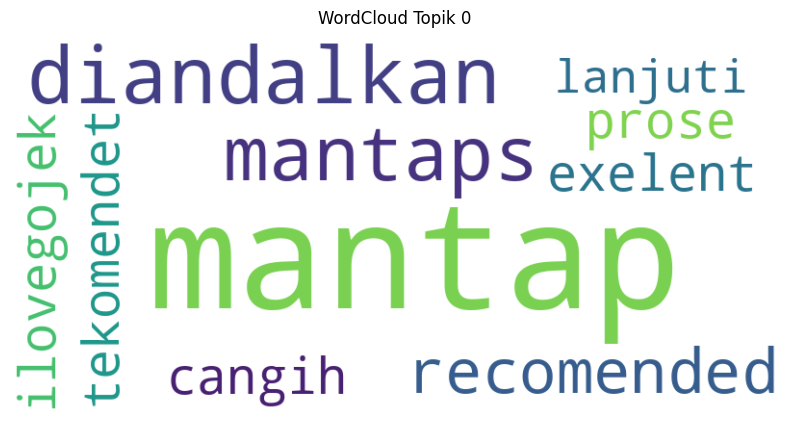

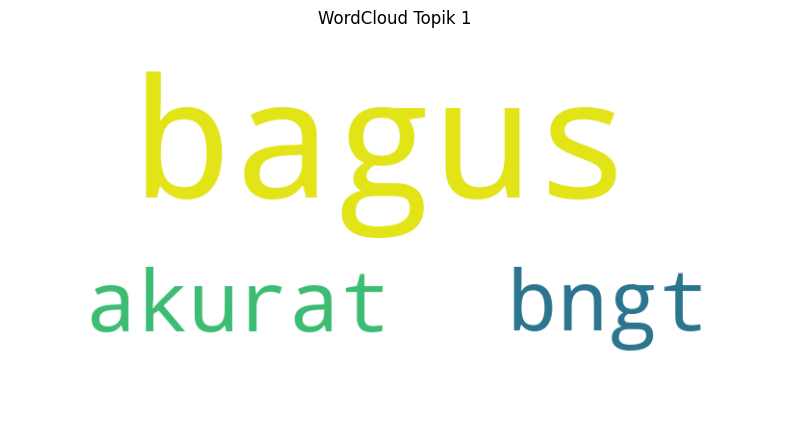

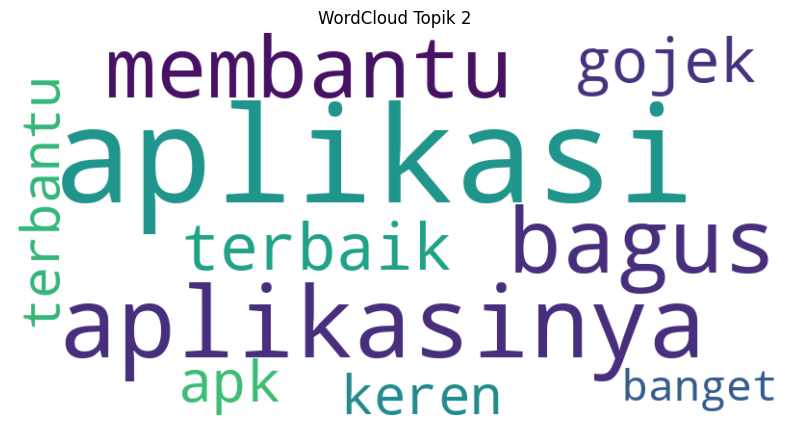

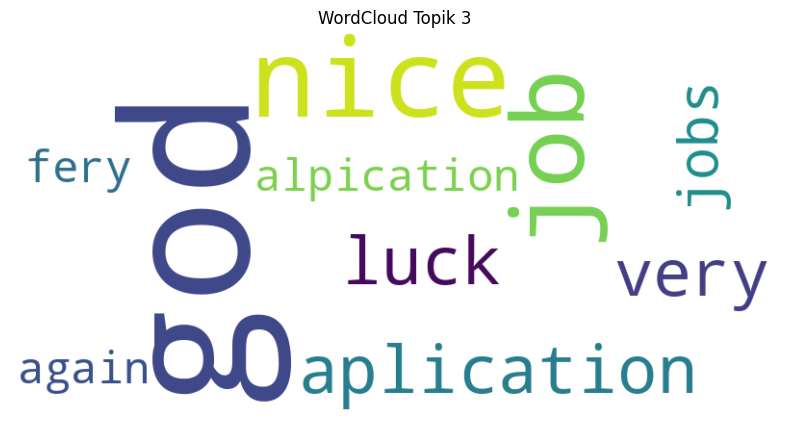

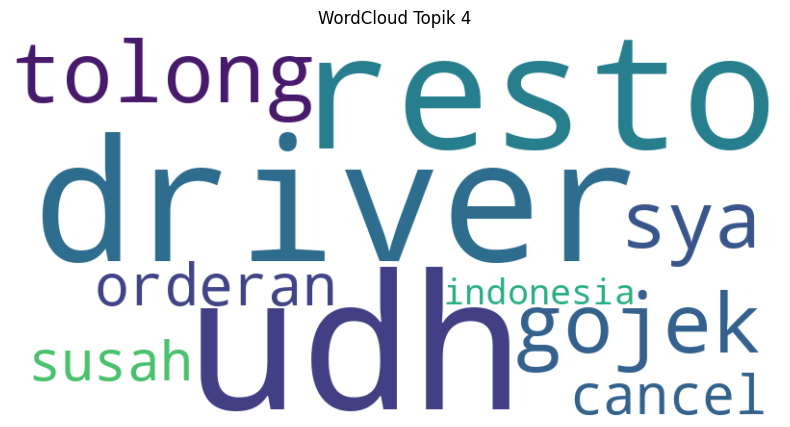

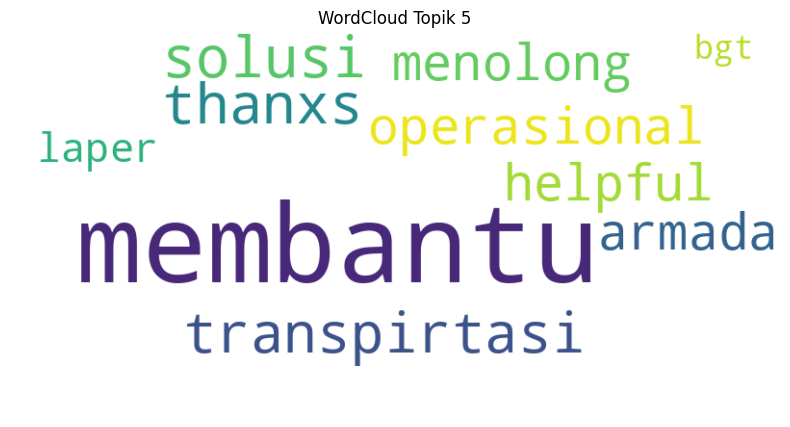

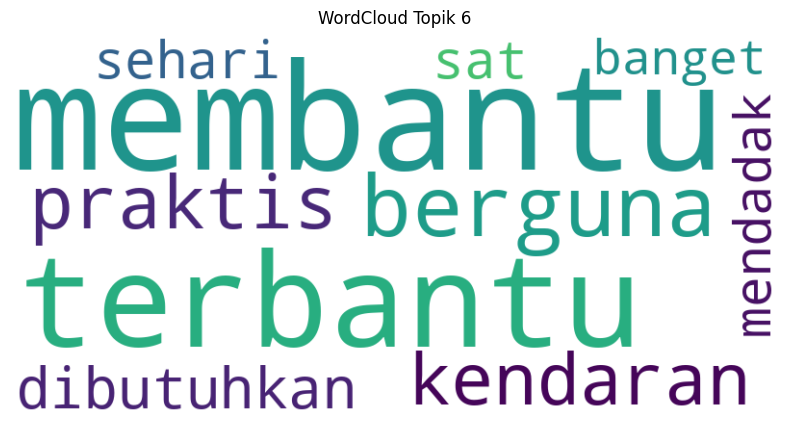

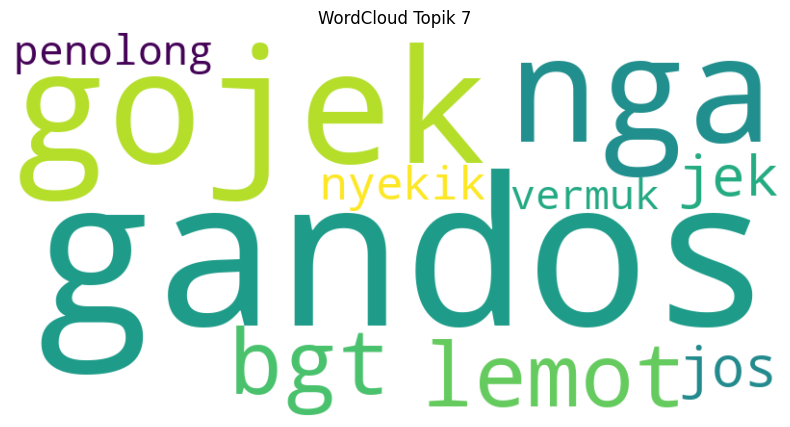

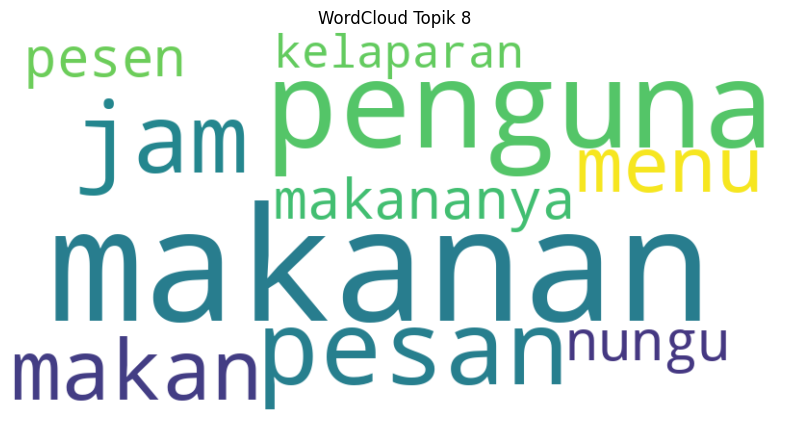

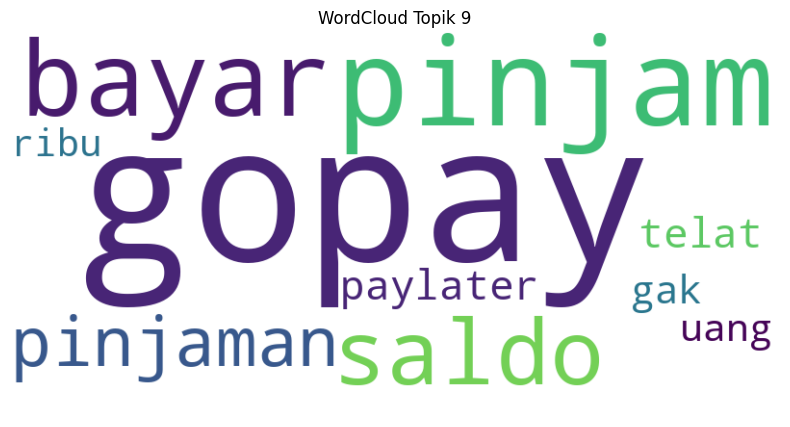

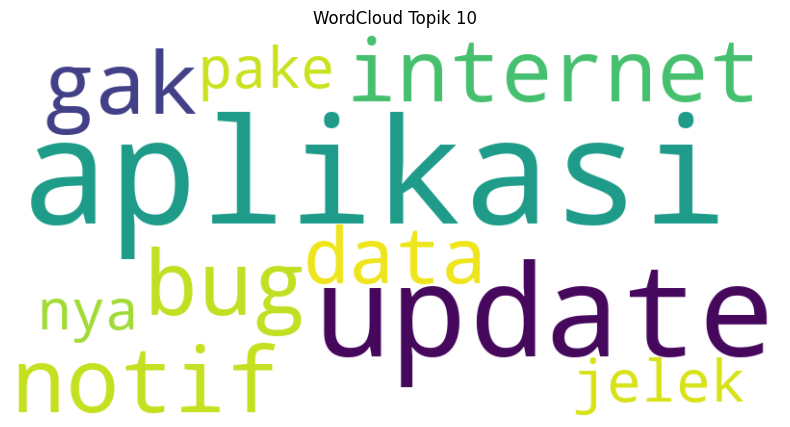

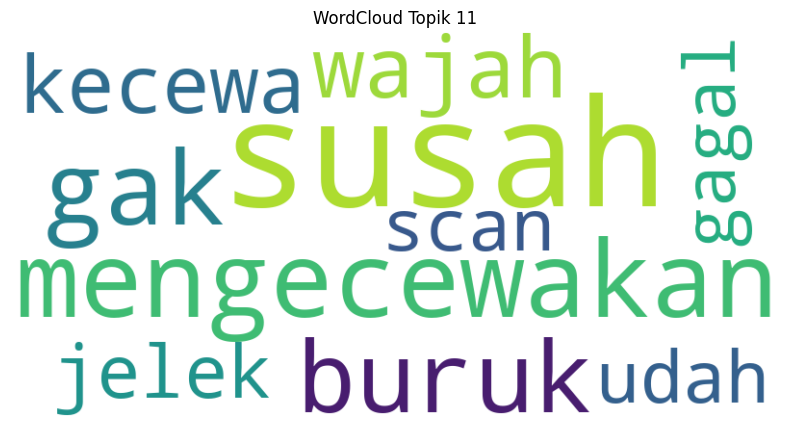

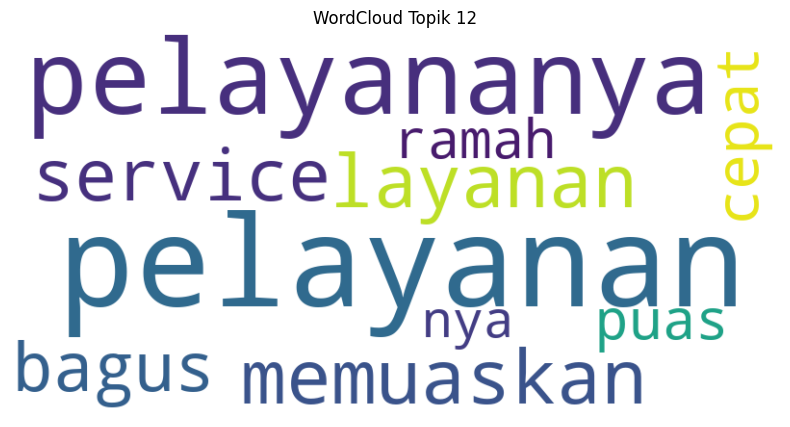

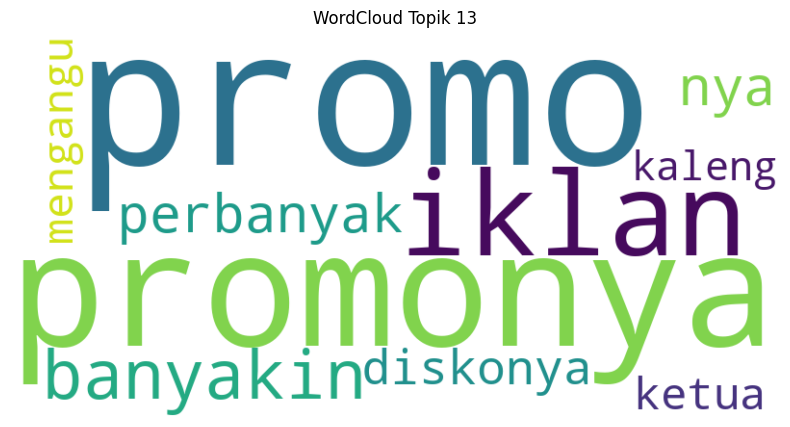

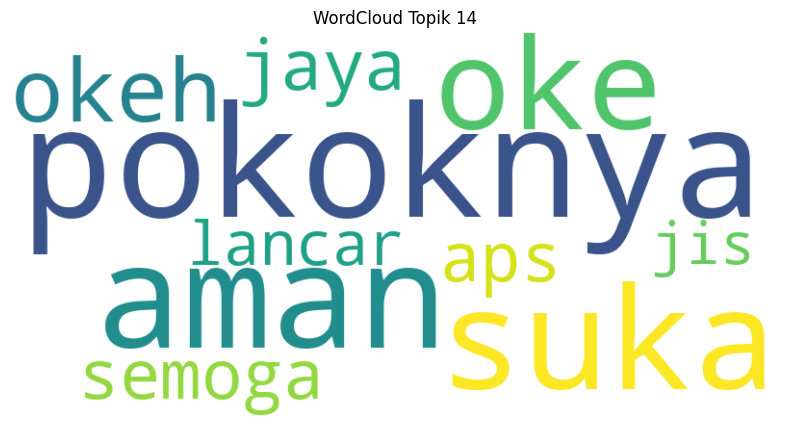

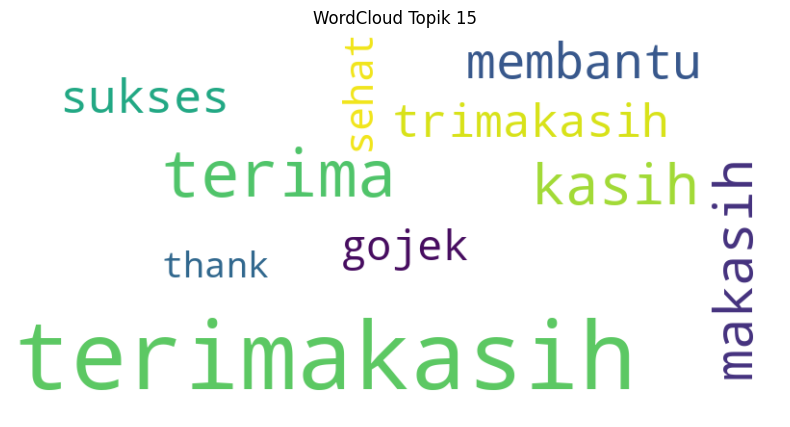

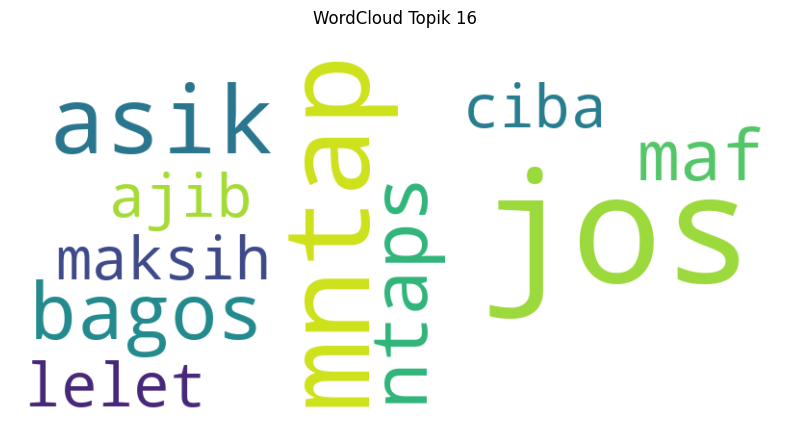

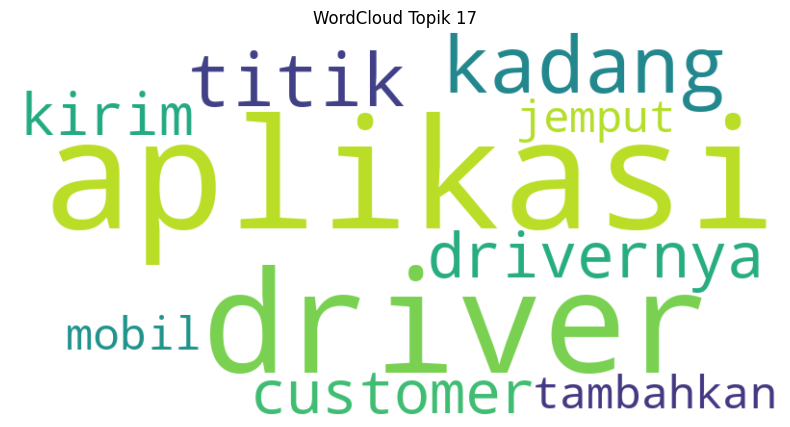

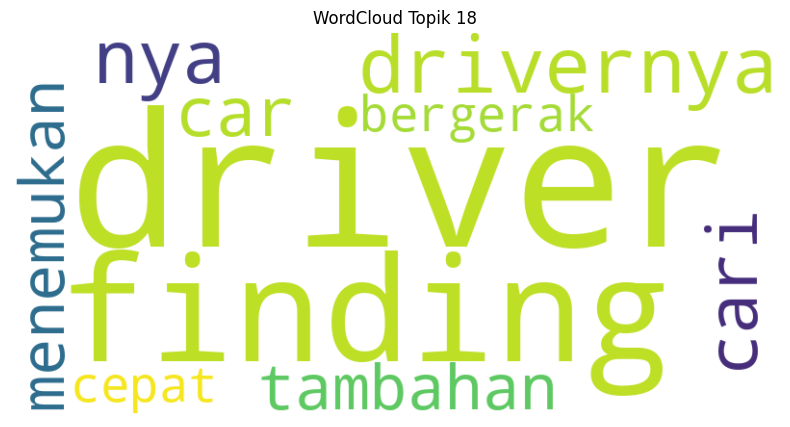

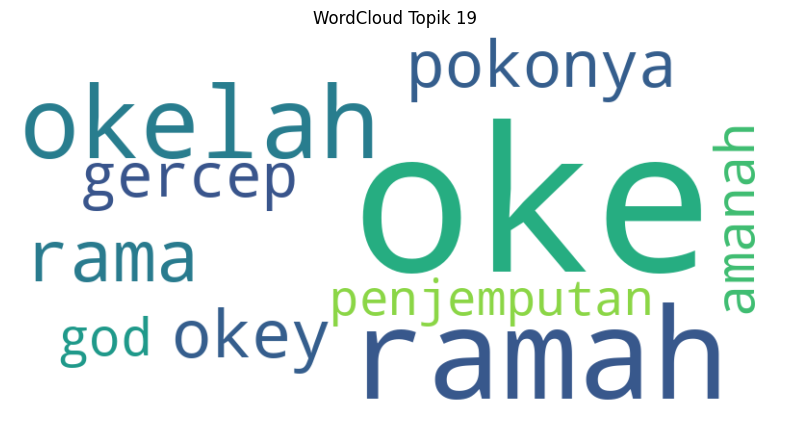

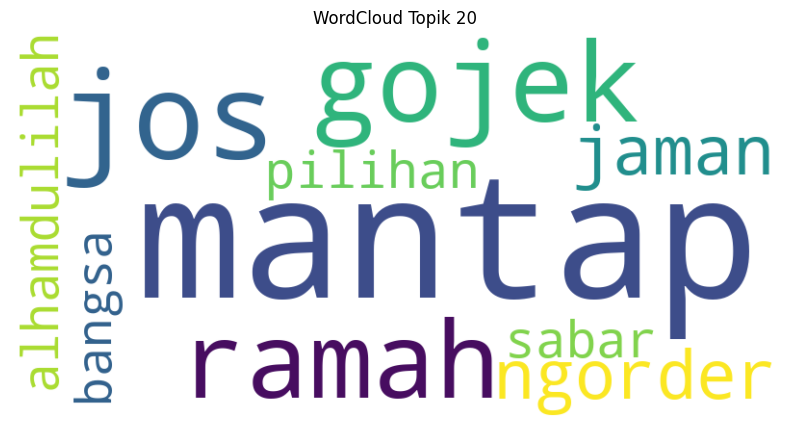

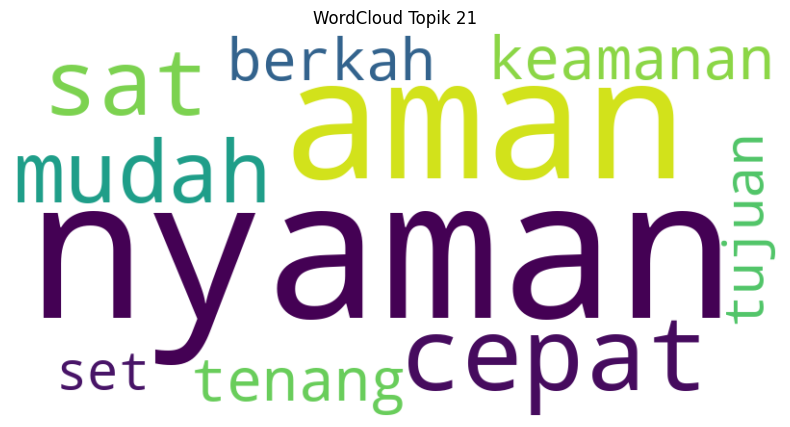

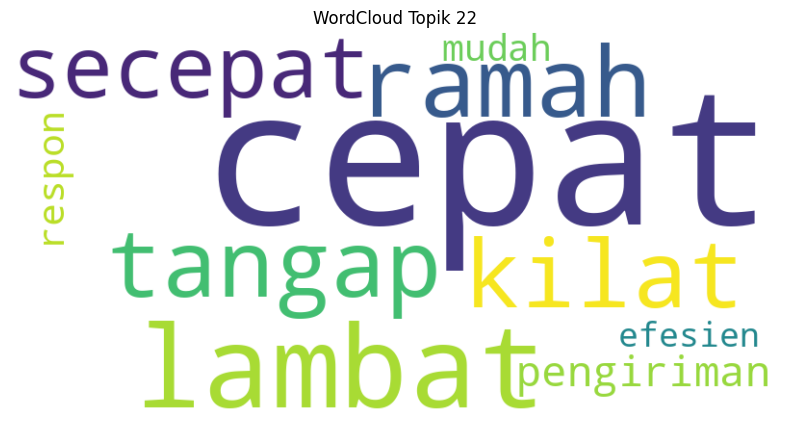

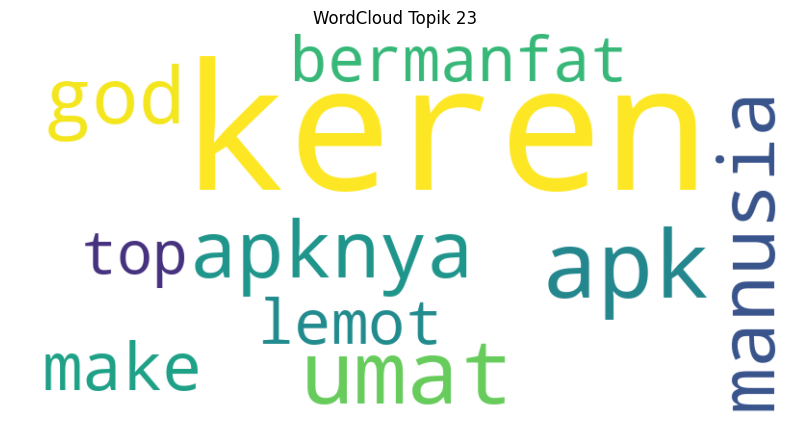

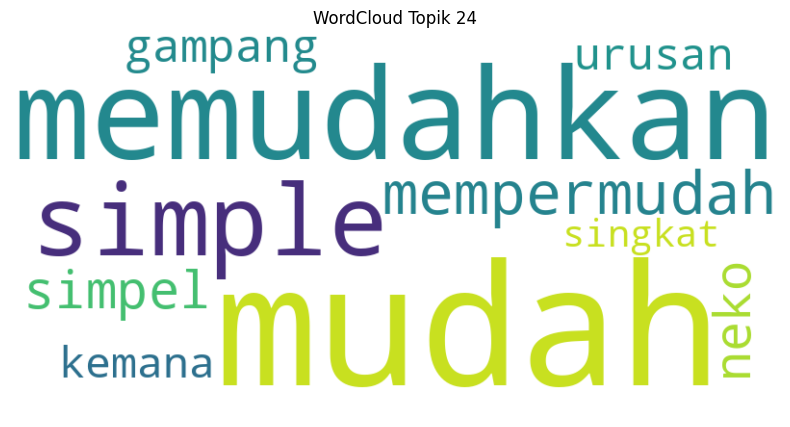

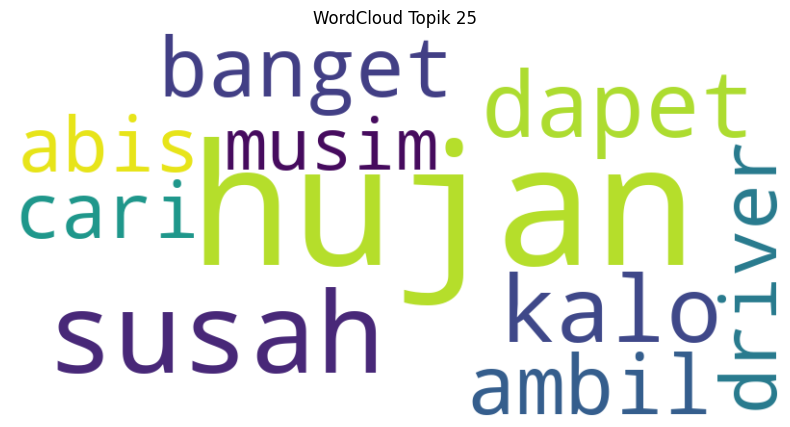

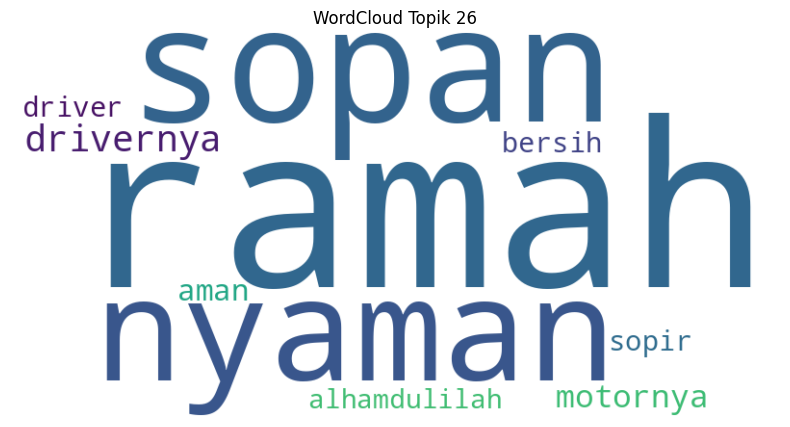

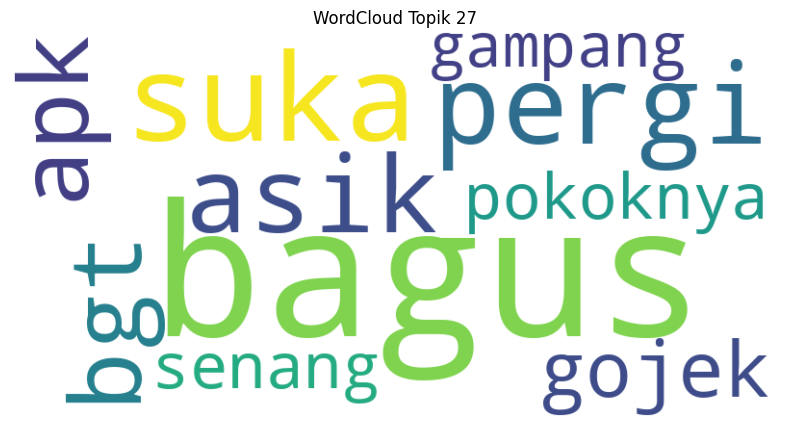

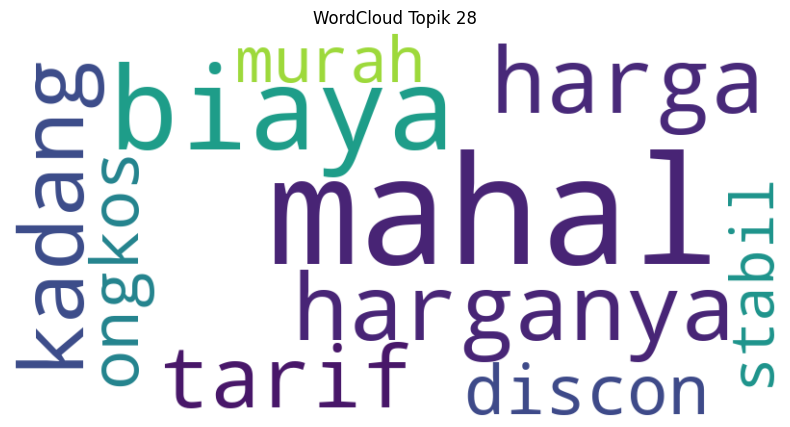

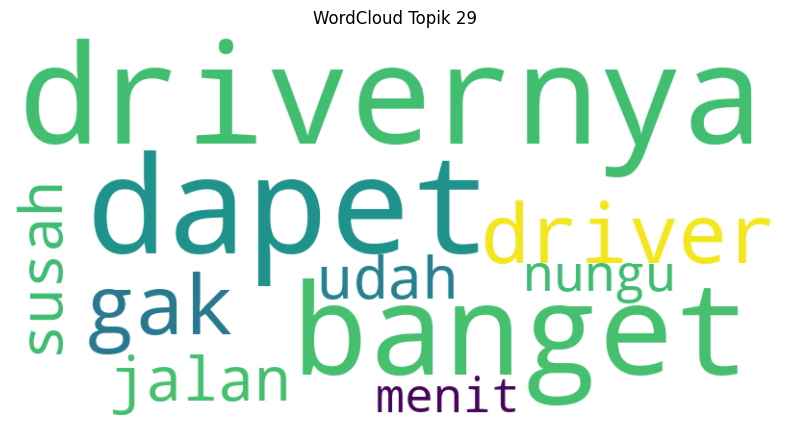

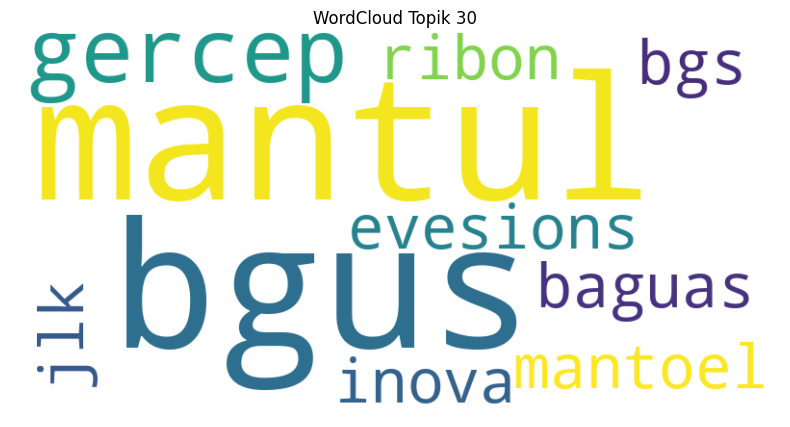

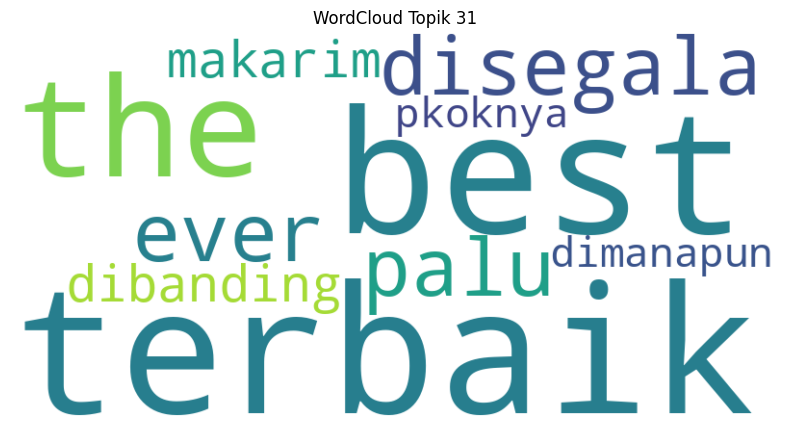

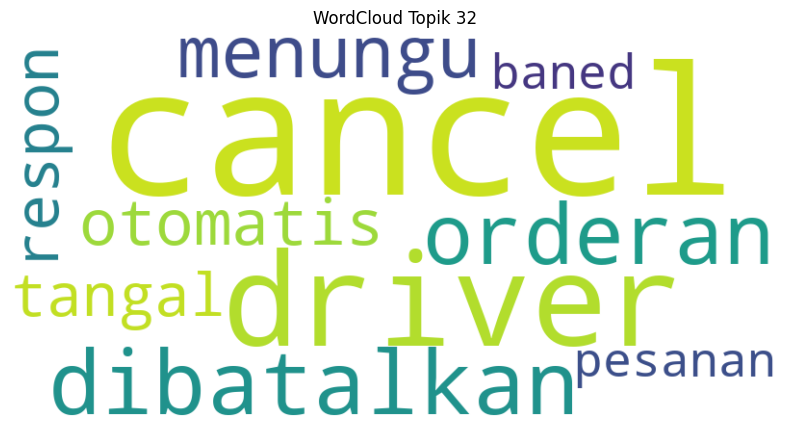

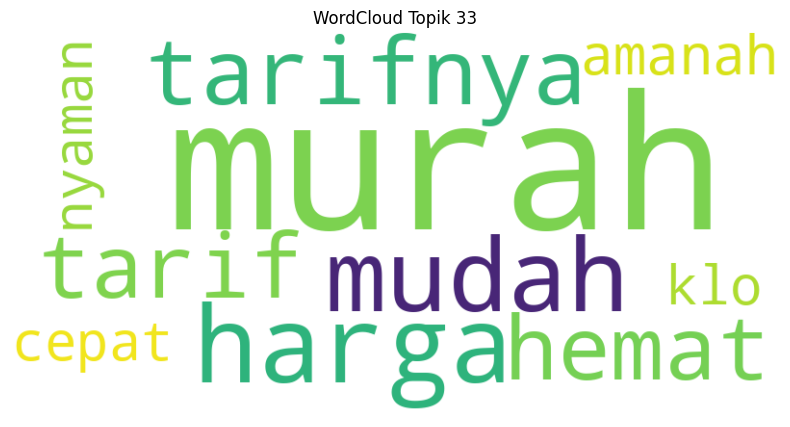

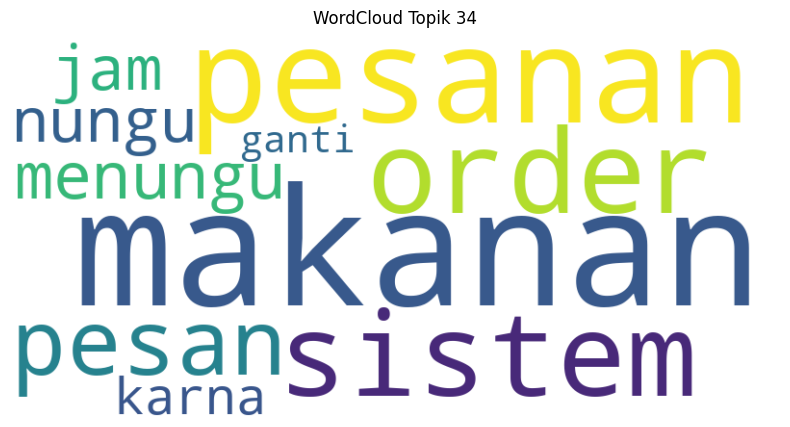

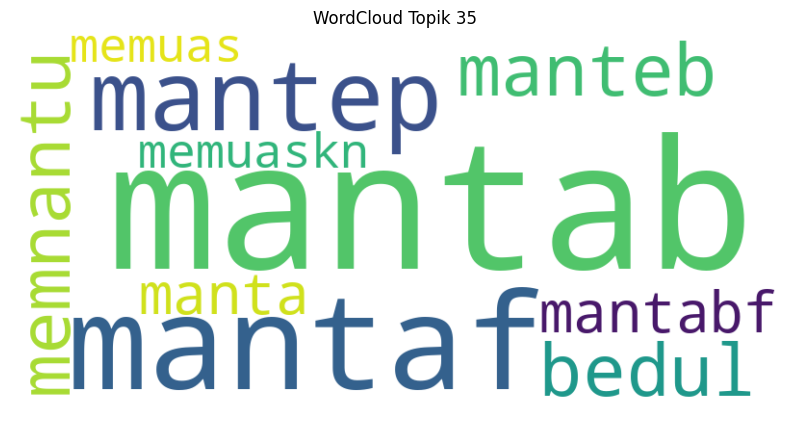

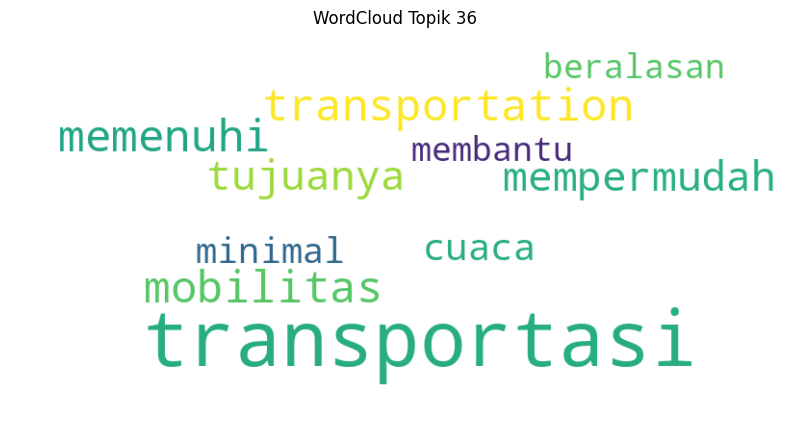

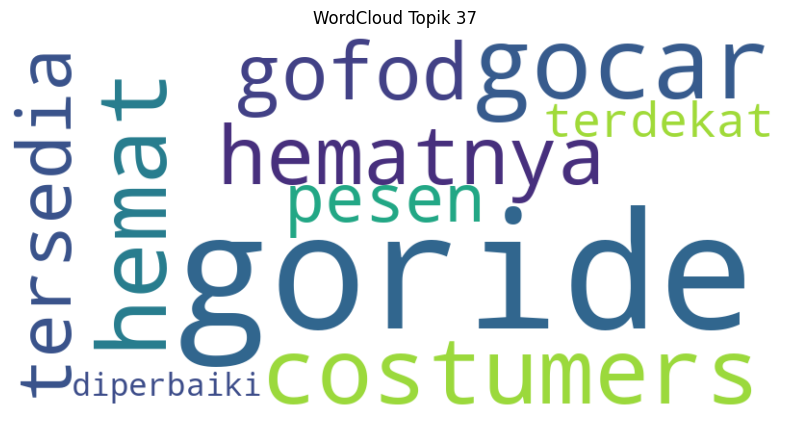

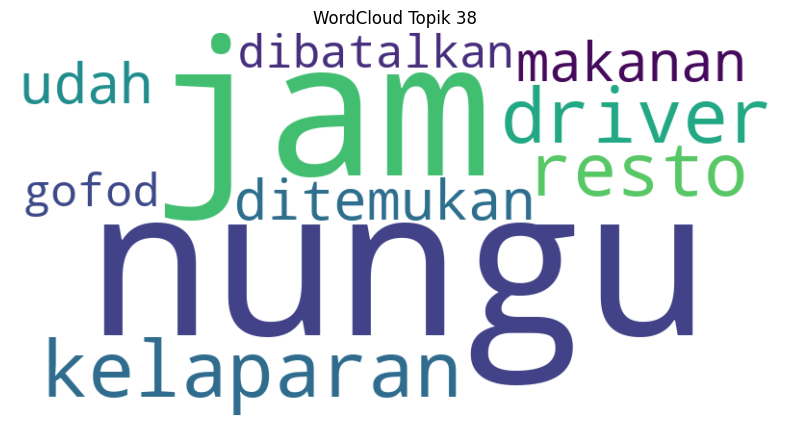

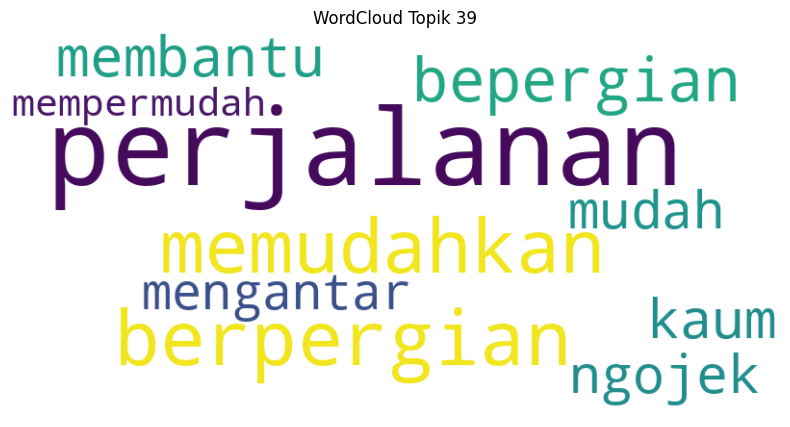

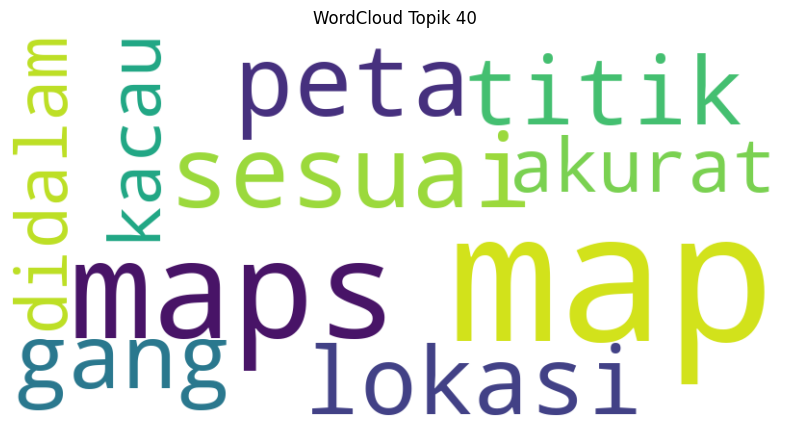

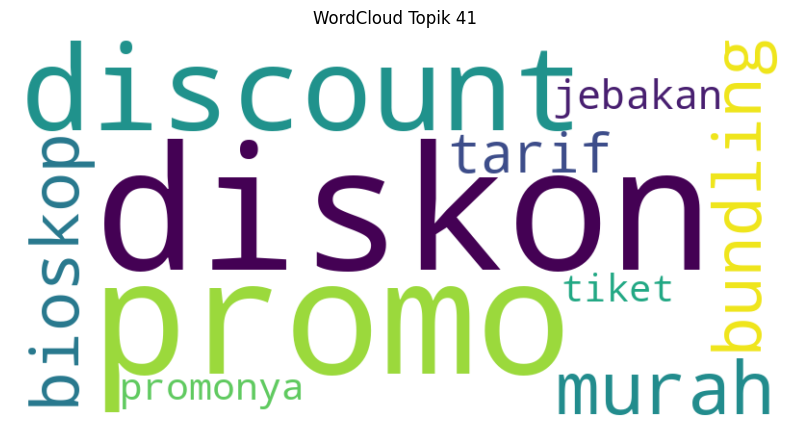

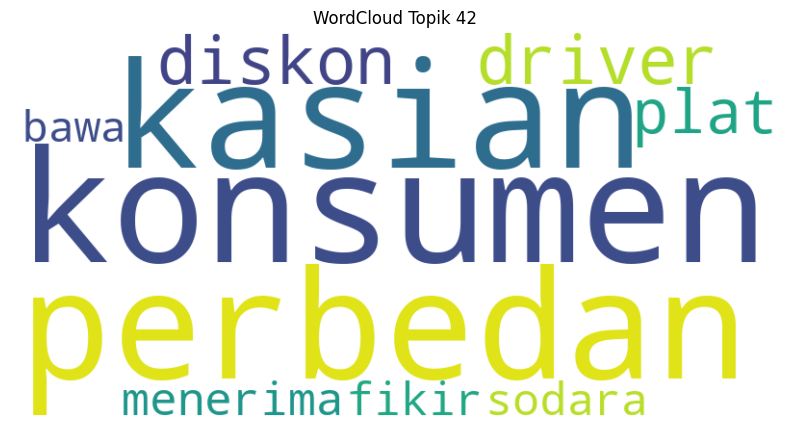

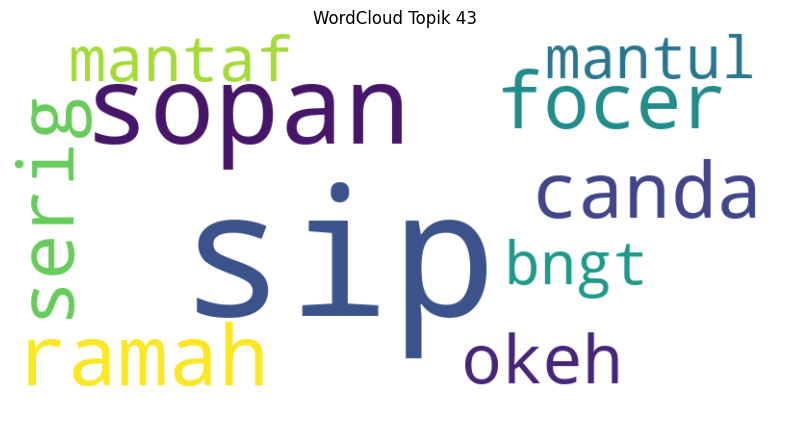

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for topic_id in topic_info["Topic"]:
    if topic_id == -1:
        continue

    words = dict(topic_model.get_topic(topic_id))
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(words)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud Topik {topic_id}")
    plt.show()


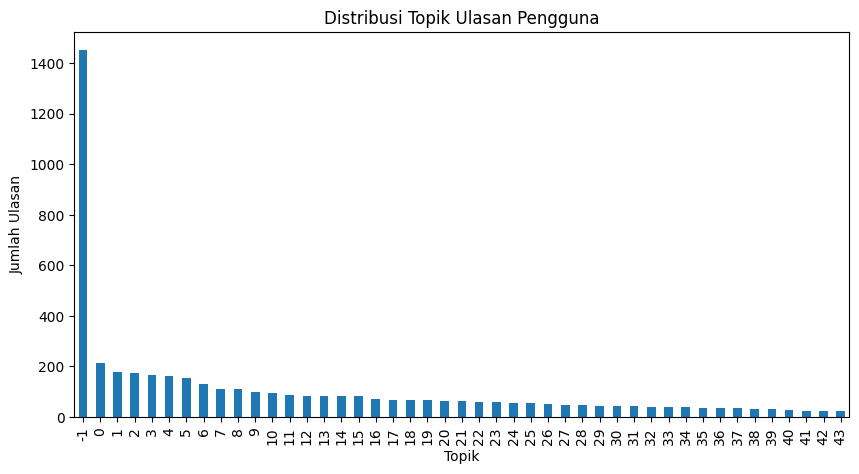

In [9]:
import matplotlib.pyplot as plt

topic_counts = df["topic"].value_counts().sort_index()

plt.figure(figsize=(10,5))
topic_counts.plot(kind="bar")
plt.title("Distribusi Topik Ulasan Pengguna")
plt.xlabel("Topik")
plt.ylabel("Jumlah Ulasan")
plt.show()


In [10]:
topic_model.visualize_topics()
